In [1]:
# Unconditional Sampling Notebook for Guided Diffusion

import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision.utils import make_grid

from guided_diffusion import dist_util
from guided_diffusion.script_util import (
    model_and_diffusion_defaults,
    create_guided_model_and_diffusion,
)
from guided_diffusion.image_datasets import load_data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42

# Set Python, NumPy, and PyTorch seeds
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# If using CUDA:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # For reproducibility
    torch.backends.cudnn.benchmark = False


In [2]:

# ==== CONFIG ====
checkpoint_path = "/home/rg625/models/conditional/cifar10/ema_0.9999_010000.pt"
num_samples = 16
batch_size = 16
image_size = 32  # CIFAR10

# ==== Set up device ====
dist_util.setup_dist()

# ==== Load model and diffusion ====
model_args = model_and_diffusion_defaults()
model_args.update(
    dict(
        image_size=image_size,
        class_cond=False,
        unet_ckpt = "/home/rg625/models/unconditional/cifar10/ema_0.9999_200000.pt"
    )
)
model, diffusion = create_guided_model_and_diffusion(**model_args)
model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
model.to(dist_util.dev())
model.eval()
model.sampling = True

/home/rg625/mnt/guided-diffusion/guided_diffusion/unet.py:940: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = th.load(path, map_location="cpu")
/tmp/ipykernel_63891/1

Loading pretrained weights from /home/rg625/models/unconditional/cifar10/ema_0.9999_200000.pt, step: N/A


In [3]:
data = load_data(
        data_dir="/home/rg625/datasets/cifar10/images/",
        batch_size=batch_size,
        image_size=image_size,
        class_cond=False,
    )

In [4]:
# ==== Sampling function ====
def sample(model, cond_fn, num_samples, noise, model_kwargs):
    samples = diffusion.p_sample_loop(
        model=model,
        shape=(num_samples, 3, image_size, image_size),
        noise=noise,
        clip_denoised=True,
        cond_fn=cond_fn,
        model_kwargs=model_kwargs,
        progress=True,
    )
    return (samples + 1) / 2  # from [-1,1] to [0,1]


In [5]:
# ==== Generate samples ====
noise = torch.randn((num_samples, 3, image_size, image_size), device = device, dtype=torch.float32)
x_start, cond = next(data)
sample_unconditional = sample(
    model.unet_model, 
    cond_fn=None, 
    num_samples=num_samples, 
    noise=noise,
    model_kwargs = {},
    )

z = model.prepare_for_sampling(x_0=x_start.to(device))
# With guidance
sample_with_condfn = sample(
    model.unet_model, 
    cond_fn=lambda x, t: model.guidance_score(x, t, z=z["encoding"]), 
    num_samples=num_samples, 
    noise=noise,
    model_kwargs = {},
)
# Without guidance (vanilla DDPM)
sample_without_condfn = sample(
    model,  # ScoreVAE acts like base model when cond_fn is None
    cond_fn=None, 
    num_samples=num_samples, 
    noise=noise,
    model_kwargs={
        "z_start": z["encoding"].to(device),
    },
)

/home/rg625/anaconda3/envs/id-diff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [00:51<00:00, 19.36it/s]


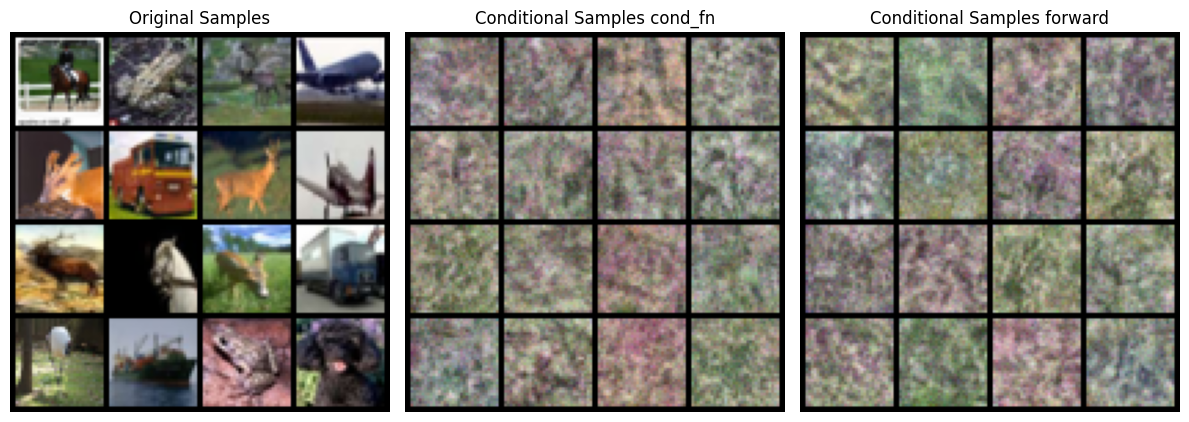

In [6]:
# ==== Visualize ====
# Create sample grids
grid_original = make_grid(x_start, nrow=4, normalize=True)
grid_unconditional = make_grid(sample_unconditional, nrow=4)
grid_with = make_grid(sample_with_condfn, nrow=4)
grid_without = make_grid(sample_without_condfn, nrow=4)

# Plot side-by-side
plt.figure(figsize=(12, 6))

# Conditional samples
plt.subplot(1, 3, 1)
plt.imshow(grid_original.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Original Samples")

# Conditional samples
# plt.subplot(1, 4, 2)
# plt.imshow(grid_unconditional.permute(1, 2, 0).cpu())
# plt.axis("off")
# plt.title("Unconditional Samples")

# Different conditional samples
plt.subplot(1, 3, 2)
plt.imshow(grid_with.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Conditional Samples cond_fn")

# Unconditional samples
plt.subplot(1, 3, 3)
plt.imshow(grid_without.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Conditional Samples forward")

plt.tight_layout()
plt.show()

1000
torch.Size([16, 3, 32, 32])


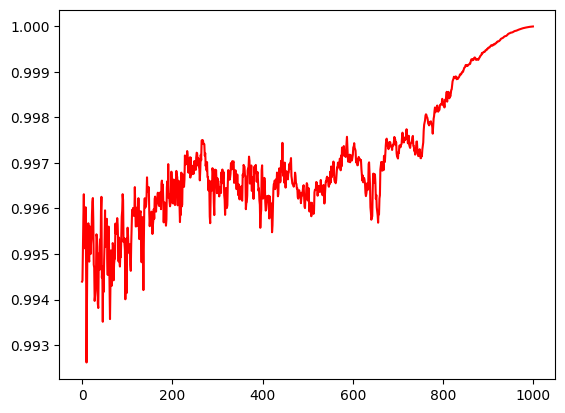

In [9]:
prior_score = model.sample_encoding["prior_score"]
conditional_score = model.sample_encoding["conditional_score"]
print(len(prior_score))
print(prior_score[0].shape)

prior_norm = []
conditional_norm = []
ratios = []
for i in range(len(prior_score)):
    prior_norm.append(torch.norm(prior_score[i]).cpu().numpy()/((torch.norm(conditional_score[i]).cpu().numpy()+torch.norm(prior_score[i]).cpu().numpy())))
    conditional_norm.append(torch.norm(conditional_score[i]).cpu().numpy()/((torch.norm(conditional_score[i]).cpu().numpy()+torch.norm(prior_score[i]).cpu().numpy()))) 

plt.plot(prior_norm, c='r')
# plt.plot(conditional_norm, c='b')
plt.show()